MSE: 4.205128205128205
R²: 0.6930395420357296


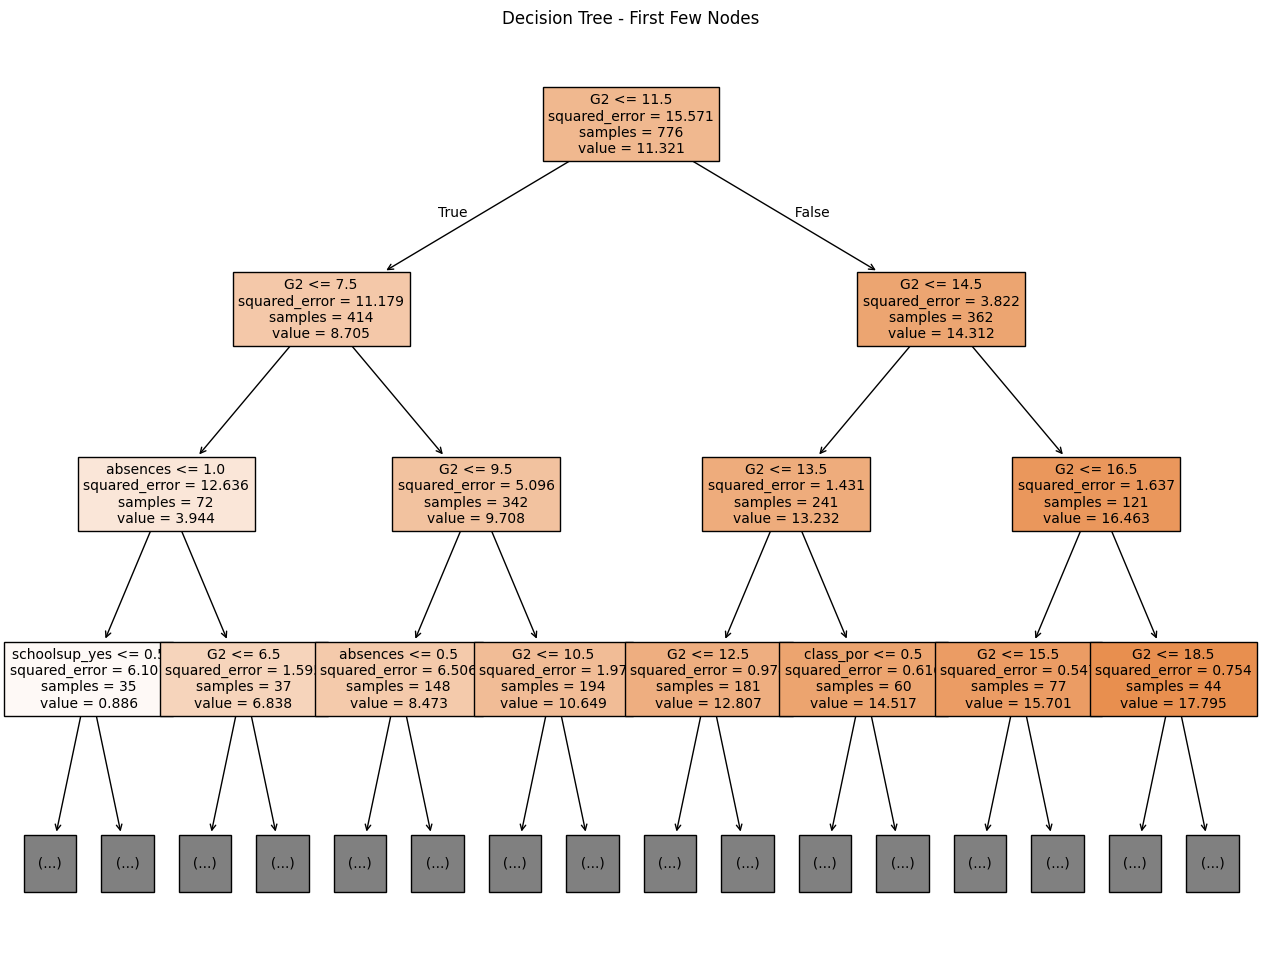

['E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/tree_model.pkl']

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# 读取清理后的数据
df = pd.read_csv("data/student_combined_cleaned.csv")

# 特征和目标
X = df.drop(columns=['G3'])
y = df['G3']

# 对分类特征进行独热编码
X = pd.get_dummies(X)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练决策树回归模型
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# 预测并评估模型
y_pred = tree_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

# 绘制决策树的前几个节点
plt.figure(figsize=(16, 12))  # 增加图形大小
plot_tree(tree_model, feature_names=X.columns, filled=True, max_depth=3, fontsize=10)  # 调整字体大小
plt.title("Decision Tree - First Few Nodes")
plt.show()

# 保存训练好的决策树模型
joblib.dump(tree_model, r"E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/tree_model.pkl")